# Introduction

> **VISET**: **Vis**ual **I**temized **SET** diagrams. Area-proportional Venn/Euler and UpSet plots that print the **member names** in each region, in Python.

Set diagrams usually label each region with just a **count** (how many genes overlap), not *which* genes, and the plain shapes are rarely drawn to scale. VISET puts the **actual members** inside each region, sizes every label to stay legible, and does it for both **Venn/Euler** and **UpSet**. For the existing tools it builds on and where they fall short, see [State of current set diagrams](state_of_set_diagrams.html).

## VISET on real gene sets

Here are three drug-target gene sets in VISET (the same ones drawn plainly under [State of current set diagrams](state_of_set_diagrams.html)): proportional ellipses from eunoia, every gene printed inside its region, and each list auto-sized to fit.

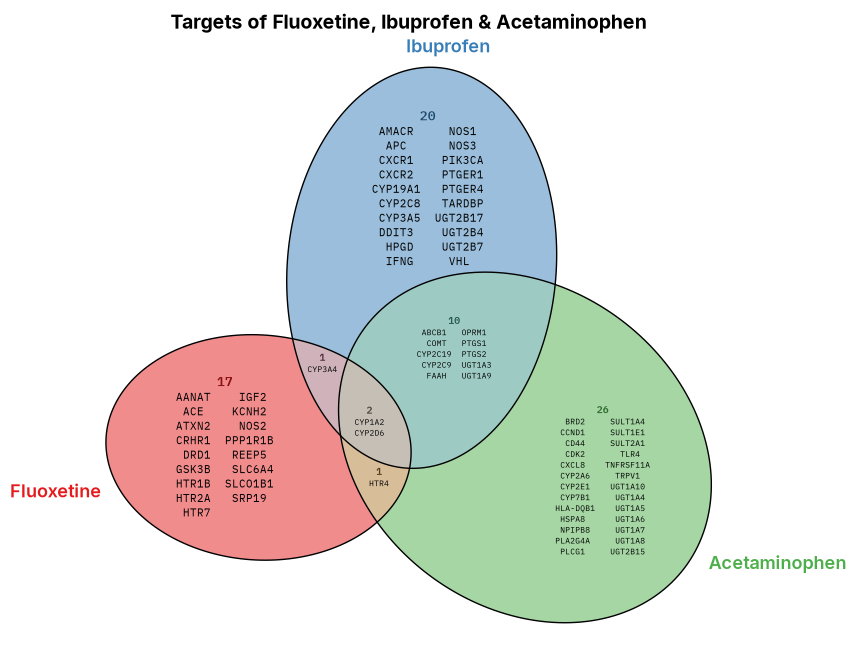

In [1]:
#| code-fold: true
#| fig-cap: "The same three drug-target gene sets in VISET: proportional ellipses, with every gene printed inside its region."
import os
import matplotlib.pyplot as plt
from matplotlib import font_manager
from viset import load, eunoia_venn

fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)

db = "Drug target sample files/" if os.path.isdir("Drug target sample files") else "../Drug target sample files/"
flu = load(db + "1. FLUOXETINE_sample.csv", "Gene names", "Fluoxetine")
ibu = load(db + "2. IBUPROFEN_sample.csv", "Gene names", "Ibuprofen")
acet = load(db + "3. ACETAMINOPHEN_sample.csv", "Gene names", "Acetaminophen")
eunoia_venn([flu, ibu, acet], colors="Set1", figsize=(9, 8),
            title="Targets of Fluoxetine, Ibuprofen & Acetaminophen")

## Install

VISET is not on PyPI. Install the latest from GitHub:

```bash
pip install git+https://github.com/mnicolee/VISET.git
```

## Quick start

Give each set a CSV with a column of member names, load them, and draw:

```python
from viset import load, eunoia_venn

ibu = load("IBUPROFEN.csv", "Gene names", "Ibuprofen")
ace = load("ACETAMINOPHEN.csv", "Gene names", "Acetaminophen")

eunoia_venn([ibu, ace], colors=["#3a7ca5", "#e08a3c"], style="round")
```

`eunoia_venn` draws proportional, itemized Venn/Euler diagrams and `upset` does the same as an UpSet plot. Each also has a Plotly version (`eunoia_venn_interactive`, `upset_interactive`) that reveals crowded regions on hover. Full setup is in [Requirements & Acknowledgements](core.html).

## The gap VISET fills

There are good tools for set visualization, but they split the job up: some draw proportional shapes, some label members, some scale to many sets, and none size the labels to fit. VISET is the one place you get itemized, auto-sized labels for **both** Venn/Euler and UpSet.

| Tool | Area-proportional? | Members shown? | Labels auto-sized to fit? | UpSet? |
|---|---|---|---|---|
| [`matplotlib-venn`](https://pypi.org/project/matplotlib-venn/) | 2 sets exact, 3 sets approximate | no, counts only | n/a | no |
| [`matplotlib-set-diagrams`](https://pypi.org/project/matplotlib-set-diagrams/) | yes (circles, 3 sets approximate) | yes, as word clouds | no | no |
| [`upsetplot`](https://upsetplot.readthedocs.io) | n/a | no, counts only | n/a | yes |
| [`eunoia`](https://github.com/jolars/eunoia) | yes (ellipses, exact for 3 sets) | no | n/a | no |
| **VISET** | yes (via eunoia ellipses) | yes, aligned columns | **yes** | yes, itemized + hover |

Put those together and VISET fills the gap: proportional shapes from eunoia, members printed inside every region, each label grown or shrunk to fit, and the same treatment for UpSet, plus an interactive hover version of each for when a region is too crowded to print.

## What VISET adds

Three things, and the last two are where it focuses:

1. **Itemization.** The actual members are written inside each region or bar, not just the counts (the figure above).
2. **Automatic font-sizing.** Every region is measured and the largest readable font is chosen, splitting a list into columns when that keeps it legible.
3. **Interactive hover.** When a region is too crowded for any legible font, an interactive version reveals its members on hover.

The same three ideas apply to both **Venn/Euler** diagrams (2 to 3 sets) and **UpSet** plots (any number of sets), each with a static (Matplotlib) and an interactive (Plotly) version.

### Automatic font-sizing

Itemization only helps if the members are readable, and regions vary enormously in size: a large single set has room to spare, while a three-way overlap can be a sliver. So VISET sizes the text per region instead of using one fixed font, and the two plot types need different geometry.

**Venn / Euler regions: fit a box inside a curved area.** A region is a curved 2-D shape (a disc, a crescent, a lens). VISET anchors a box at the region's deepest point and grows it outward until each side hits the boundary, then grows the member font as large as will fill that box. Because the whole box sits inside the region, the shape's outline can never cross the text. If a single tall column would force the font below a legible floor, VISET adds columns: the block gets shorter and wider and a larger font fits. The same rule runs in the overlaps, where the box simply sits between the arcs.

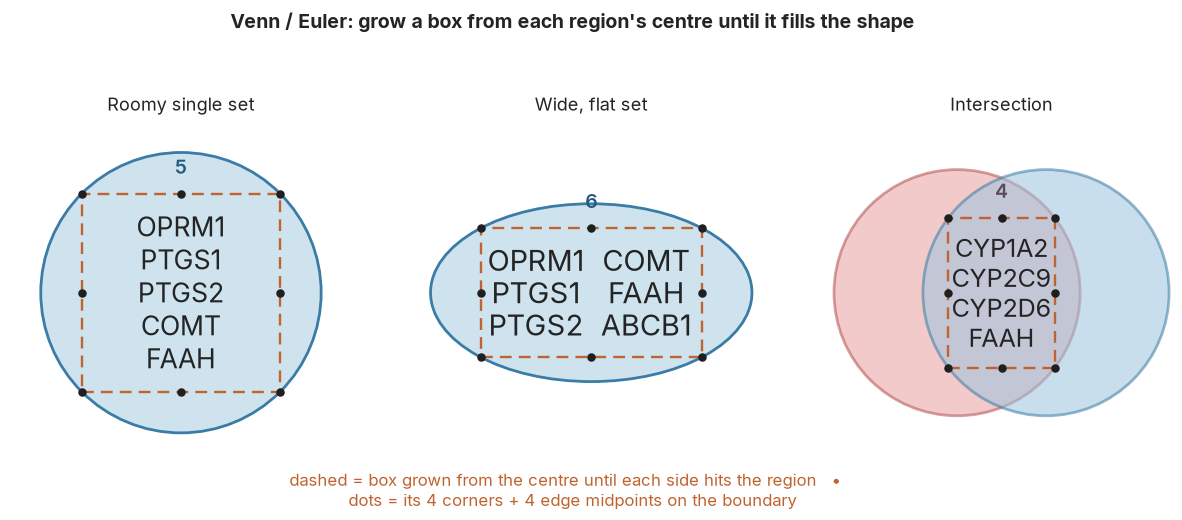

In [2]:
#| code-fold: true
#| fig-cap: "Grow a box from each region's centre until it fills the shape, then fit the biggest font."
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Rectangle, Ellipse, Circle

fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

INK, BOX, DOT, FILL, EDGE = "#242424", "#c0632f", "#1f1f1f", "#cfe3ef", "#3a7ca5"
gx = np.linspace(0, 10, 300); gy = np.linspace(0, 10, 300); GX, GY = np.meshgrid(gx, gy)

def max_rect(mask):
    "Largest axis-aligned rectangle inside `mask`; returns (x0, y0, x1, y1)."
    h, w = mask.shape
    heights = np.zeros(w, int); best = 0; box = None
    for i in range(h):
        for j in range(w):
            heights[j] = heights[j] + 1 if mask[i, j] else 0
        st = []
        for j in range(w + 1):
            cur = heights[j] if j < w else 0
            while st and heights[st[-1]] > cur:
                t = st.pop(); l = st[-1] + 1 if st else 0; rgt = j - 1
                a = heights[t] * (rgt - l + 1)
                if a > best:
                    best = a; box = (l, rgt, i - heights[t] + 1, i)
            st.append(j)
    l, rgt, ti, bi = box
    return gx[l], gy[ti], gx[rgt], gy[bi]

def draw_box(ax, x0, y0, x1, y1, lines, cols):
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=BOX, lw=1.7, ls=(0, (5, 3)), zorder=5))
    xm, ym = (x0 + x1) / 2, (y0 + y1) / 2
    pts = [(x, y) for x in (x0, xm, x1) for y in (y0, ym, y1) if not (x == xm and y == ym)]
    ax.scatter([p[0] for p in pts], [p[1] for p in pts], s=26, color=DOT, zorder=6)
    bw, bh = x1 - x0, y1 - y0
    per = -(-len(lines) // cols)
    fs = max(min(bh * 24 / (per * 1.45), (bw / cols) * 24 / (max(len(s) for s in lines) * 0.63), 21), 8)
    step = bh / (per + 1)
    xs = [x0 + bw * (c + 0.5) / cols for c in range(cols)]
    for c in range(cols):
        for r in range(per):
            k = c * per + r
            if k < len(lines):
                ax.text(xs[c], y1 - (r + 1) * step, lines[k], ha="center", va="center", fontsize=fs, color=INK)
    return x0, y0, x1, y1

def count(ax, x0, x1, y1, s, color):
    ax.text((x0 + x1) / 2, y1 + 0.45, s, ha="center", va="bottom", fontsize=14, fontweight="semibold", color=color)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
for ax in axes:
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.set_aspect("equal"); ax.axis("off")
ax = axes[0]
ax.add_patch(Circle((5, 5), 4.1, facecolor=FILL, edgecolor=EDGE, lw=2))
b = draw_box(ax, *max_rect((GX - 5) ** 2 + (GY - 5) ** 2 <= 4.1 ** 2), ["OPRM1", "PTGS1", "PTGS2", "COMT", "FAAH"], 1)
count(ax, b[0], b[2], b[3], "5", "#215a7d")
ax.set_title("Roomy single set", fontsize=13, color=INK, pad=8)
ax = axes[1]
ax.add_patch(Ellipse((5, 5), 9.4, 5.2, facecolor=FILL, edgecolor=EDGE, lw=2))
b = draw_box(ax, *max_rect(((GX - 5) / 4.7) ** 2 + ((GY - 5) / 2.6) ** 2 <= 1), ["OPRM1", "PTGS1", "PTGS2", "COMT", "FAAH", "ABCB1"], 2)
count(ax, b[0], b[2], b[3], "6", "#215a7d")
ax.set_title("Wide, flat set", fontsize=13, color=INK, pad=8)
ax = axes[2]
ax.add_patch(Circle((3.7, 5), 3.6, facecolor="#e8a0a0", edgecolor="#b45252", lw=2, alpha=0.55))
ax.add_patch(Circle((6.3, 5), 3.6, facecolor="#9dc3de", edgecolor=EDGE, lw=2, alpha=0.55))
m = ((GX - 3.7) ** 2 + (GY - 5) ** 2 <= 3.6 ** 2) & ((GX - 6.3) ** 2 + (GY - 5) ** 2 <= 3.6 ** 2)
b = draw_box(ax, *max_rect(m), ["CYP1A2", "CYP2C9", "CYP2D6", "FAAH"], 1)
count(ax, b[0], b[2], b[3], "4", "#5a4a5a")
ax.set_title("Intersection", fontsize=13, color=INK, pad=8)
fig.suptitle("Venn / Euler: grow a box from each region's centre until it fills the shape",
             fontsize=14, fontweight="bold", color=INK, y=1.02)
fig.text(0.5, 0.1, "dashed = box grown from the centre until each side hits the region   \u2022   \n"
         "dots = its 4 corners + 4 edge midpoints on the boundary", ha="center", fontsize=12, color=BOX)
plt.show()

**UpSet bars: the box is already there.** An UpSet bar is a rectangle to begin with, so there is nothing to search for: VISET takes the largest font at which the longest name fits the bar's fixed **width** and all the members stack within its **height**, adding columns when a bar is wide enough.

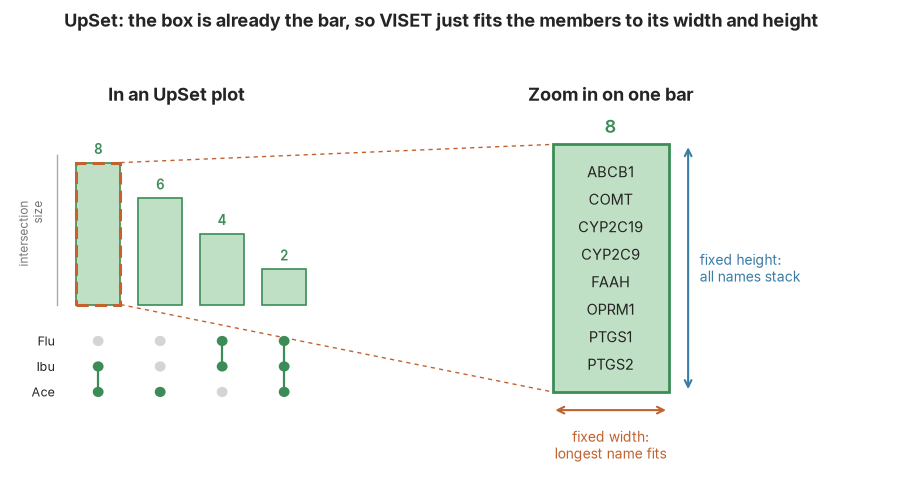

In [3]:
#| code-fold: true
#| fig-cap: "An UpSet bar is already a rectangle, so VISET just fits the members to its width and height."
import os
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch

fp = "Font" if os.path.isdir("Font") else "../Font"
for f in font_manager.findSystemFonts(fontpaths=[fp]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

INK, ACC, BOX = "#242424", "#3a7ca5", "#c0632f"
GFILL, GEDGE = "#bfe0c4", "#3c8c57"
fig, ax = plt.subplots(figsize=(11.5, 5.2))
ax.set_xlim(0, 23); ax.set_ylim(0, 11); ax.axis("off")
ax.text(4.3, 10.2, "In an UpSet plot", ha="center", fontsize=13, fontweight="bold", color=INK)
sizes = [8, 6, 4, 2]; bxs = [1.7, 3.3, 4.9, 6.5]; bw0 = 1.15; base = 4.6; maxh = 3.9
ax.plot([1.2, 1.2], [base, base + maxh + 0.2], color="#aaaaaa", lw=1)
ax.text(0.9, base + maxh / 2, "intersection\nsize", ha="right", va="center", fontsize=8.5, color="#777777", rotation=90)
for x, sz in zip(bxs, sizes):
    h = maxh * sz / max(sizes)
    ax.add_patch(Rectangle((x, base), bw0, h, facecolor=GFILL, edgecolor=GEDGE, lw=1.2))
    ax.text(x + bw0 / 2, base + h + 0.15, str(sz), ha="center", va="bottom", fontsize=9.5, color=GEDGE, fontweight="semibold")
ax.add_patch(Rectangle((bxs[0], base), bw0, maxh, fill=False, edgecolor=BOX, lw=2.2, ls=(0, (4, 2)), zorder=6))
rows = ["Flu", "Ibu", "Ace"]; row_y = [3.6, 2.9, 2.2]
member = [[0, 0, 1, 1], [1, 0, 1, 1], [1, 1, 0, 1]]
for r, sy in enumerate(row_y):
    ax.text(1.15, sy, rows[r], ha="right", va="center", fontsize=9, color=INK)
    for c, x in enumerate(bxs):
        ax.add_patch(Circle((x + bw0 / 2, sy), 0.14, facecolor=GEDGE if member[r][c] else "#d4d4d4", edgecolor="none", zorder=3))
for c, x in enumerate(bxs):
    ys = [row_y[r] for r in range(3) if member[r][c]]
    if len(ys) > 1:
        ax.plot([x + bw0 / 2] * 2, [min(ys), max(ys)], color=GEDGE, lw=1.6, zorder=2)
ex0, ey0, ew, eh = 14.0, 2.2, 3.0, 6.8
hx1 = bxs[0] + bw0
ax.plot([hx1, ex0], [base + maxh, ey0 + eh], color=BOX, lw=1, ls=(0, (3, 3)), zorder=1)
ax.plot([hx1, ex0], [base, ey0], color=BOX, lw=1, ls=(0, (3, 3)), zorder=1)
ax.text(ex0 + ew / 2, 10.2, "Zoom in on one bar", ha="center", fontsize=13, fontweight="bold", color=INK)
ax.add_patch(Rectangle((ex0, ey0), ew, eh, facecolor=GFILL, edgecolor=GEDGE, lw=2))
genes = ["ABCB1", "COMT", "CYP2C19", "CYP2C9", "FAAH", "OPRM1", "PTGS1", "PTGS2"]
ax.text(ex0 + ew / 2, ey0 + eh + 0.2, "8", ha="center", va="bottom", fontsize=13, fontweight="semibold", color=GEDGE)
step = eh / (len(genes) + 1)
for i, g in enumerate(genes):
    ax.text(ex0 + ew / 2, ey0 + eh - (i + 1) * step, g, ha="center", va="center", fontsize=10.5, color=INK)
ax.add_patch(FancyArrowPatch((ex0, ey0 - 0.5), (ex0 + ew, ey0 - 0.5), arrowstyle="<->", mutation_scale=12, color=BOX, lw=1.5))
ax.text(ex0 + ew / 2, ey0 - 1.0, "fixed width:\nlongest name fits", ha="center", va="top", fontsize=10, color=BOX)
ax.add_patch(FancyArrowPatch((ex0 + ew + 0.5, ey0), (ex0 + ew + 0.5, ey0 + eh), arrowstyle="<->", mutation_scale=12, color=ACC, lw=1.5))
ax.text(ex0 + ew + 0.8, ey0 + eh / 2, "fixed height:\nall names stack", ha="left", va="center", fontsize=10, color=ACC)
fig.suptitle("UpSet: the box is already the bar, so VISET just fits the members to its width and height",
             fontsize=13, fontweight="bold", color=INK, y=1.0)
plt.show()

### When a region is crowded: hover

Even with auto-sizing, a small region packed with members can only support a tiny font. For those cases VISET provides interactive (Plotly) versions of both plotters: the counts stay drawn in place, and the full member list appears in a **hover tooltip** instead of being squeezed into the figure.

- **Venn:** [static](venn.html) prints members in-region and auto-sizes them; [interactive](venn_interactive.html) shows them on hover.
- **UpSet:** [static](upset.html) lists members inside each bar; [interactive](upset_interactive.html) shows them on hover.

To install and load your own data, start with [Requirements & Acknowledgements](core.html).

## Limitations

**Area-proportionality has a ceiling that grows with the number of sets.** Making every region's *area* equal its *count* is a geometry problem, and it gets harder as sets are added: the number of regions to satisfy (up to 2ⁿ − 1) grows far faster than the freedom the shapes provide (a circle is 3 numbers, an ellipse 5).

- **2 sets:** always exact, with any shape.
- **3 sets:** exact with **ellipses** (what VISET uses, via eunoia); only approximate with **circles** (`matplotlib_venn`, `matplotlib-set-diagrams`). Three ellipses have enough freedom to place all seven regions area-true; three circles usually cannot.
- **4 or more sets:** no arrangement of shapes can keep every region area-true. The solver minimises the error but cannot reach zero, so some regions come out the wrong size, empty overlaps can appear where the data has none, and thin slivers leave nowhere to print a label.

Ellipses degrade far more gracefully than circles. Measured on four NSAID target sets with eunoia's own error metric (`diag_error`, the worst-region area error, as a percent of the diagram):

| sets | circles (`matplotlib_venn`, `matplotlib-set-diagrams`) | ellipses (VISET / eunoia) |
|---|---|---|
| 2 | exact | exact |
| 3 | ~0.4% | **exact** |
| 4 | ~6% | ~0.6% |
| 5 | ~3% | ~1.4% |

So of the available tools, circle-based ones are the weakest and VISET's ellipses the strongest, but past three sets even ellipses are no longer exact.

**Itemization stays correct; only its placement suffers.** VISET reads which members fall in each region straight from your data, so the member *lists* are always accurate, whatever the geometry does. What breaks past three sets is only *where* those names can be printed: a region squeezed to a sliver, or one the shapes cannot form at all, has no room for its label.

**What to do past three sets: reach for UpSet, not a bigger Venn.** An UpSet plot is a bar chart, so it has no geometric ceiling: it stays exact and fully itemized for any number of sets. Use the interactive UpSet when many intersections crowd the static bars. The interactive *Venn* helps with crowding too, but it is the same ellipse layout underneath, so it does not escape the four-set geometry problem. VISET will still draw a four-set Venn if you ask, but above three sets an UpSet is the honest choice.

**The in-diagram font is fixed to monospace.** VISET aligns each region's member list into columns by padding names to a set character width, which only lines up in a **monospace** typeface. So the names and counts *inside* every region are always drawn in monospace; the `font` option changes only the outside text (title and set labels, Inter by default). This is deliberate: a proportional font would leave the columns ragged.